In [48]:
import numpy as np
import matplotlib.pyplot as plt
import random

bonos = {
    'A': {'precio': 500, 'cantidad': 5,  'rendimiento': 0.15},
    'B': {'precio': 700, 'cantidad': 6,  'rendimiento': 0.05},
    'C': {'precio': 300, 'cantidad': 10, 'rendimiento': 0.03},
    'D': {'precio': 800, 'cantidad': 3,  'rendimiento': 0.10},
    'E': {'precio': 400, 'cantidad': 7,  'rendimiento': 0.10},
}

nombres   = list(bonos.keys())
precios   = np.array([b['precio']      for b in bonos.values()])
cantidades= np.array([b['cantidad']    for b in bonos.values()])
rendimientos = np.array([b['rendimiento'] for b in bonos.values()])

CAPITAL = 10_000   # Capital disponible del cliente (ajusta según el enunciado)
N_BONOS = len(nombres)

print("Bonos disponibles:")
print(f"{'Bono':<6} {'Precio':>8} {'Cantidad':>10} {'Rendimiento':>13}")
for n, p, c, r in zip(nombres, precios, cantidades, rendimientos):
    print(f"{n:<6} {p:>8} {c:>10} {r:>13.2f}")
print(f"\nCapital del cliente: ${CAPITAL:,}")

Bonos disponibles:
Bono     Precio   Cantidad   Rendimiento
A           500          5          0.15
B           700          6          0.05
C           300         10          0.03
D           800          3          0.10
E           400          7          0.10

Capital del cliente: $10,000


In [49]:

TAM_POBLACION = 100
NUM_GENERACIONES = 200
PROB_CRUZA = 0.8
PROB_MUTACION = 0.1

def crear_individuo():
    return [random.randint(0, c) for c in cantidades]

def crear_poblacion(n):
    return [crear_individuo() for _ in range(n)]


def funcion_objetivo(individuo):
    """Calcula el rendimiento total; 0 si supera el capital."""
    costo = sum(individuo[i] * precios[i] for i in range(N_BONOS))
    if costo > CAPITAL:
        return 0  # Penalización: solución no válida
    return sum(individuo[i] * precios[i] * rendimientos[i] for i in range(N_BONOS))


def fitness(individuo):
    return funcion_objetivo(individuo)

def seleccion_torneo(poblacion, k=3):
    torneo = random.sample(poblacion, k)
    return max(torneo, key=fitness)

def cruza(padre1, padre2):
    if random.random() < PROB_CRUZA:
        punto = random.randint(1, N_BONOS - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1[:], padre2[:]

def mutacion(individuo):
    for i in range(N_BONOS):
        if random.random() < PROB_MUTACION:
            individuo[i] = random.randint(0, cantidades[i])
    return individuo

random.seed(42)
poblacion = crear_poblacion(TAM_POBLACION)
historial_mejor = []
historial_promedio = []

for gen in range(NUM_GENERACIONES):
    # Evaluación
    fits = [fitness(ind) for ind in poblacion]
    historial_mejor.append(max(fits))
    historial_promedio.append(np.mean(fits))

    # Nueva generación
    nueva_poblacion = []
    while len(nueva_poblacion) < TAM_POBLACION:
        p1 = seleccion_torneo(poblacion)
        p2 = seleccion_torneo(poblacion)
        h1, h2 = cruza(p1, p2)
        nueva_poblacion.append(mutacion(h1))
        nueva_poblacion.append(mutacion(h2))

    poblacion = nueva_poblacion[:TAM_POBLACION]

# Mejor solución encontrada
mejor = max(poblacion, key=fitness)
mejor_rendimiento = fitness(mejor)
mejor_costo = sum(mejor[i] * precios[i] for i in range(N_BONOS))

print("═" * 45)
print("  RESULTADO — AG MANUAL")
print("═" * 45)
for i, n in enumerate(nombres):
    print(f"  Bono {n}: {mejor[i]} unidades")
print(f"\n  Costo total   : ${mejor_costo:,.2f}")
print(f"  Rendimiento   : ${mejor_rendimiento:,.2f}")
print("═" * 45)

═════════════════════════════════════════════
  RESULTADO — AG MANUAL
═════════════════════════════════════════════
  Bono A: 5 unidades
  Bono B: 3 unidades
  Bono C: 0 unidades
  Bono D: 3 unidades
  Bono E: 7 unidades

  Costo total   : $9,800.00
  Rendimiento   : $1,000.00
═════════════════════════════════════════════


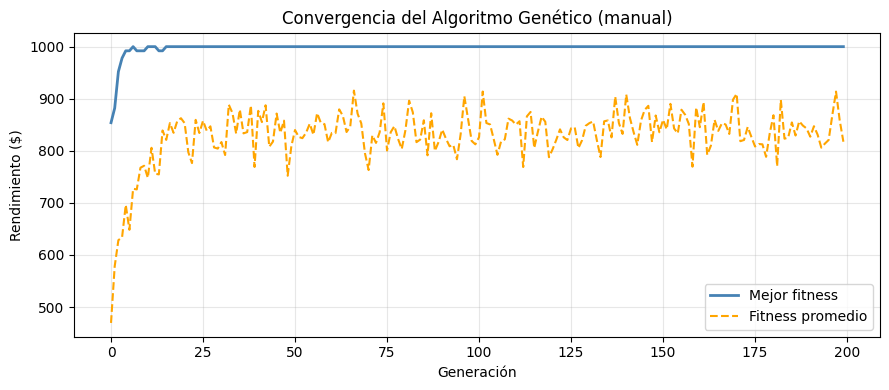

In [50]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(historial_mejor,    label='Mejor fitness',   color='steelblue', lw=2)
ax.plot(historial_promedio, label='Fitness promedio', color='orange',    lw=1.5, linestyle='--')
ax.set_xlabel('Generación')
ax.set_ylabel('Rendimiento ($)')
ax.set_title('Convergencia del Algoritmo Genético (manual)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

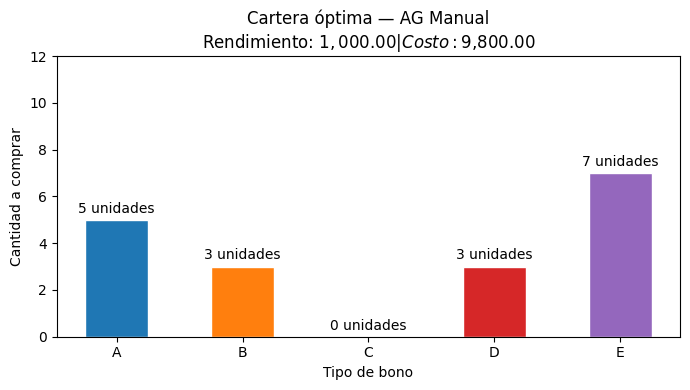

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(nombres, mejor, color=colores, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%d unidades', padding=3)
ax.set_xlabel('Tipo de bono')
ax.set_ylabel('Cantidad a comprar')
ax.set_title(f'Cartera óptima — AG Manual\nRendimiento: ${mejor_rendimiento:,.2f} | Costo: ${mejor_costo:,.2f}')
ax.set_ylim(0, max(cantidades) + 2)
plt.tight_layout()
plt.show()

In [52]:
import sys
!{sys.executable} -m pip install deap

In [53]:
from deap import base, creator, tools, algorithms

if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

for i, (n, c) in enumerate(zip(nombres, cantidades)):
    toolbox.register(f"attr_bono{i}", random.randint, 0, c)

toolbox.register(
    "individual", tools.initCycle, creator.Individual,
    [getattr(toolbox, f"attr_bono{i}") for i in range(N_BONOS)], n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Función de evaluación para DEAP
def evaluar(individuo):
    return (funcion_objetivo(list(individuo)),)  # Debe devolver una tupla

toolbox.register("evaluate",  evaluar)
toolbox.register("mate",      tools.cxOnePoint)
toolbox.register("mutate",    tools.mutUniformInt,
                 low=0, up=list(cantidades), indpb=0.2)
toolbox.register("select",    tools.selTournament, tournsize=3)

# Ejecutar AG con DEAP
random.seed(42)
pop = toolbox.population(n=TAM_POBLACION)
hof = tools.HallOfFame(1)   # Guarda el mejor individuo

stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register("max",  np.max)
stats.register("mean", np.mean)

pop_final, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=PROB_CRUZA, mutpb=PROB_MUTACION,
    ngen=NUM_GENERACIONES,
    stats=stats, halloffame=hof, verbose=False
)

mejor_deap = list(hof[0])
rend_deap  = funcion_objetivo(mejor_deap)
costo_deap = sum(mejor_deap[i] * precios[i] for i in range(N_BONOS))

print("═" * 45)
print("  RESULTADO — DEAP")
print("═" * 45)
for i, n in enumerate(nombres):
    print(f"  Bono {n}: {mejor_deap[i]} unidades")
print(f"\n  Costo total   : ${costo_deap:,.2f}")
print(f"  Rendimiento   : ${rend_deap:,.2f}")
print("═" * 45)

═════════════════════════════════════════════
  RESULTADO — DEAP
═════════════════════════════════════════════
  Bono A: 5 unidades
  Bono B: 3 unidades
  Bono C: 0 unidades
  Bono D: 3 unidades
  Bono E: 7 unidades

  Costo total   : $9,800.00
  Rendimiento   : $1,000.00
═════════════════════════════════════════════


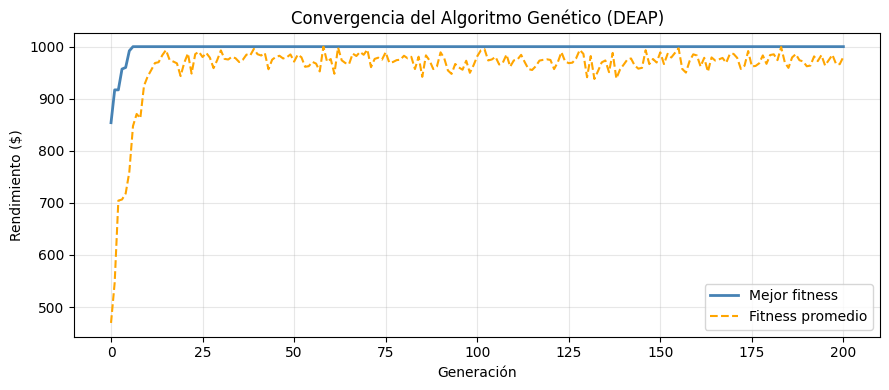

In [54]:
gen_vals  = log.select("gen")
max_vals  = log.select("max")
mean_vals = log.select("mean")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gen_vals, max_vals,  label='Mejor fitness',   color='steelblue', lw=2)
ax.plot(gen_vals, mean_vals, label='Fitness promedio', color='orange',    lw=1.5, linestyle='--')
ax.set_xlabel('Generación')
ax.set_ylabel('Rendimiento ($)')
ax.set_title('Convergencia del Algoritmo Genético (DEAP)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Análisis comparativo

| Aspecto | AG Manual | DEAP |
|---|---|---|
| **Función objetivo** | Implementada explícitamente: suma precio×cantidad×rendimiento con penalización si supera capital | Envuelta en `evaluar()` que devuelve tupla; misma lógica interna |
| **Fitness** | Función directa que devuelve float | Objeto `FitnessMax` con `weights=(1.0,)` para maximizar |
| **Selección** | Torneo programado manualmente con `random.sample` | `tools.selTournament` de DEAP |
| **Cruza** | Un punto, programada manualmente | `tools.cxOnePoint` |
| **Mutación** | Reemplaza gen por valor aleatorio con probabilidad `PROB_MUTACION` | `tools.mutUniformInt` con `indpb` por gen |
| **Ventaja** | Control total del proceso, fácil de depurar | Código más compacto, estadísticas integradas, Hall of Fame |